In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38
0,ACSM1,10.914760,11.135962,8.891566,8.074361,9.557551,10.132283,10.019072,8.925043,11.817970,...,7.659350,6.397556,6.226404,5.630004,7.850567,6.779979,5.882256,10.540738,7.262209,7.532407
1,ADORA2B,5.110096,5.805840,4.750283,5.620902,5.434974,5.514895,4.450006,6.229374,4.439311,...,6.540154,5.116456,5.080135,7.398721,6.450155,3.579958,5.938070,6.692122,6.385460,5.950856
2,AGPAT1,3.896571,5.078981,4.389263,5.705530,5.356997,5.326282,5.437688,4.551041,2.857657,...,5.213546,5.277771,6.954467,7.280251,6.796259,8.176044,6.867025,6.206010,7.782533,6.400674
3,BTBD16,6.838794,6.487988,6.991046,5.690952,6.632153,6.535228,6.927929,4.979223,7.734810,...,4.949167,4.854093,2.889749,5.578432,5.914876,6.037106,4.780228,3.544489,3.142159,4.833111
4,CCDC178,6.137514,6.115845,5.544265,6.502288,8.371001,6.477630,8.866079,5.789687,5.656918,...,4.466889,4.313042,3.611286,4.570975,5.151161,3.790559,4.200692,4.406053,4.664216,4.987756


In [ ]:
data = data.T

In [ ]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
#X = X.apply(pd.to_numeric)
X


,ACSM1,ADORA2B,AGPAT1,BTBD16,CCDC178,CD207,CLRN1,CMA1,CSMD1,DDT,...,SFRP4,SIK1,SLC2A14,SORCS3,STC1,TBC1D3L,TNFRSF17,TYR,USP17L2,WDR46
1,10.91476,5.110096,3.896571,6.838794,6.137514,6.335811,6.009826,4.404689,8.698855,3.646425,...,12.193521,5.697186,2.97466,5.043856,6.742106,4.391362,5.723762,7.119836,8.620417,4.919325
2,11.135962,5.80584,5.078981,6.487988,6.115845,4.977656,5.474359,5.22186,7.239703,3.538015,...,10.48046,5.022233,4.24729,4.857951,4.822149,4.3735,6.082677,6.200747,8.470901,4.8774
3,8.891566,4.750283,4.389263,6.991046,5.544265,5.854893,6.827014,5.897843,10.042353,4.492789,...,11.926017,4.8805,3.793164,3.88119,7.631016,4.57199,5.470134,5.550446,8.192874,3.748831
4,8.074361,5.620902,5.70553,5.690952,6.502288,5.733583,4.6523,5.626731,8.580342,3.771152,...,13.494115,6.238118,2.781264,5.574711,8.175455,4.230194,6.473276,5.648787,7.811523,3.628753
5,9.557551,5.434974,5.356997,6.632153,8.371001,6.031605,5.919477,4.324369,7.79012,3.969257,...,11.788102,6.211392,3.135282,3.558551,6.543452,4.989646,6.105548,6.003599,7.399032,4.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6.779979,3.579958,8.176044,6.037106,3.790559,5.955599,8.112708,3.799325,6.478235,3.457107,...,10.890283,6.371103,5.944549,7.714985,9.056544,2.989828,5.051926,4.590912,7.227312,7.534752
68,5.882256,5.93807,6.867025,4.780228,4.200692,7.120193,7.008641,5.27548,6.822246,3.674302,...,11.551356,4.638456,5.725493,7.030303,9.135109,4.42579,4.72124,4.575075,6.103253,6.043637
69,10.540738,6.692122,6.20601,3.544489,4.406053,8.428116,6.119198,3.879046,8.752773,3.514716,...,9.344778,6.806512,4.146754,4.050462,10.532865,5.542763,4.414228,4.553074,5.016077,5.212523
70,7.262209,6.38546,7.782533,3.142159,4.664216,6.850532,4.242906,4.150065,6.151992,5.022798,...,10.195798,9.094513,3.853907,4.198532,11.917931,5.721694,5.591699,2.992995,2.595225,4.808556


In [ ]:
import numpy as np

In [ ]:
import numpy as np
import pandas as pd
import pickle
import os

from sklearn.svm import SVC
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# BASE DIRECTORY SETUP
# ============================================================
base_dir = "/content/drive/MyDrive/SVM_LINEAR/10_10"

os.makedirs(base_dir, exist_ok=True)
print(f"Results will be saved in base directory: ./{base_dir}/")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# ── Updated param grid ──────────────────────────────────────
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': list(range(100, 1001, 100))   # 100, 200, ..., 1000
}
# ────────────────────────────────────────────────────────────

model = SVC(
    kernel='linear',
    random_state=42,
    gamma='auto',
    probability=True
    # max_iter is now tuned via param_grid, so removed from here
)

# ============================================================
# GRID SEARCH CV
# ============================================================
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {param_grid}")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv(os.path.join(base_dir, 'svm_linear_gridsearchcv_full_results.csv'), index=False)
print(f"\nSaved full GridSearchCV results as: {base_dir}/svm_linear_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
print(f"Best C:        {grid_search.best_params_['C']}")
print(f"Best max_iter: {grid_search.best_params_['max_iter']}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ============================================================
# RESULTS FOR EACH FOLD (Best C + Best max_iter)
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS")
print("="*60)

fold_results = []
fold_count = 0

for train_idx, test_idx in cv.split(X, y):
    fold_count += 1

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    fold_model = SVC(
        kernel='linear',
        random_state=42,
        C=grid_search.best_params_['C'],
        max_iter=grid_search.best_params_['max_iter'],   # ← best max_iter
        probability=True
    )
    fold_model.fit(X_train, y_train)

    y_pred = fold_model.predict(X_test)
    y_prob = fold_model.predict_proba(X_test)[:, 1]

    fold_row = {
        'fold_number':      fold_count,
        'train_size':       len(train_idx),
        'test_size':        len(test_idx),
        'accuracy_test':    accuracy_score(y_test, y_pred),
        'precision_test':   precision_score(y_test, y_pred),
        'recall_test':      recall_score(y_test, y_pred),
        'f1_test':          f1_score(y_test, y_pred),
        'roc_auc_test':     roc_auc_score(y_test, y_prob),
        'mcc_test':         matthews_corrcoef(y_test, y_pred),
        'accuracy_train':   accuracy_score(y_train, fold_model.predict(X_train)),
        'precision_train':  precision_score(y_train, fold_model.predict(X_train)),
        'recall_train':     recall_score(y_train, fold_model.predict(X_train)),
        'f1_train':         f1_score(y_train, fold_model.predict(X_train)),
    }

    fold_results.append(fold_row)

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(os.path.join(base_dir, 'svm_linear_fold_results_best_C.csv'), index=False)
print(f"Saved fold-level results as: {base_dir}/svm_linear_fold_results_best_C.csv")

# ============================================================
# RESULTS FOR EACH C + max_iter COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION")
print("="*60)

all_c_fold_results = []

for combo_idx, (c_val, iter_val) in enumerate(
    [(c, it) for c in param_grid['C'] for it in param_grid['max_iter']]
):
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        c_model = SVC(
            kernel='linear',
            random_state=42,
            C=c_val,
            max_iter=iter_val,       # ← varied max_iter
            probability=True
        )
        c_model.fit(X_train, y_train)

        y_pred = c_model.predict(X_test)
        y_prob = c_model.predict_proba(X_test)[:, 1]

        all_c_fold_results.append({
            'C_value':              c_val,
            'max_iter':             iter_val,
            'fold_number':          fold_idx + 1 + (combo_idx * 100),
            'split_repeat':         (fold_idx // 10) + 1,
            'fold_within_repeat':   (fold_idx % 10) + 1,
            'train_size':           len(train_idx),
            'test_size':            len(test_idx),
            'accuracy_test':        accuracy_score(y_test, y_pred),
            'precision_test':       precision_score(y_test, y_pred),
            'recall_test':          recall_score(y_test, y_pred),
            'f1_test':              f1_score(y_test, y_pred),
            'roc_auc_test':         roc_auc_score(y_test, y_prob),
            'mcc_test':             matthews_corrcoef(y_test, y_pred),
            'accuracy_train':       accuracy_score(y_train, c_model.predict(X_train)),
            'precision_train':      precision_score(y_train, c_model.predict(X_train)),
            'recall_train':         recall_score(y_train, c_model.predict(X_train)),
            'f1_train':             f1_score(y_train, c_model.predict(X_train)),
        })

all_c_fold_df = pd.DataFrame(all_c_fold_results)
all_c_fold_df.to_csv(os.path.join(base_dir, 'svm_linear_all_C_fold_results.csv'), index=False)

# Summary by C + max_iter
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        subset = all_c_fold_df[
            (all_c_fold_df['C_value'] == c_val) &
            (all_c_fold_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C':              c_val,
            'max_iter':       iter_val,
            'accuracy_mean':  subset['accuracy_test'].mean(),
            'accuracy_sd':    subset['accuracy_test'].std(),
            'precision_mean': subset['precision_test'].mean(),
            'precision_sd':   subset['precision_test'].std(),
            'recall_mean':    subset['recall_test'].mean(),
            'recall_sd':      subset['recall_test'].std(),
            'f1_mean':        subset['f1_test'].mean(),
            'f1_sd':          subset['f1_test'].std(),
            'roc_auc_mean':   subset['roc_auc_test'].mean(),
            'roc_auc_sd':     subset['roc_auc_test'].std(),
            'mcc_mean':       subset['mcc_test'].mean(),
            'mcc_sd':         subset['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(base_dir, 'svm_linear_c_summary_by_fold.csv'), index=False)

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open(os.path.join(base_dir, "svm_linear_best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

print(f"\nSaved best model as: {base_dir}/svm_linear_best_model.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)
print(f"Base Directory: ./{base_dir}/")
print("1. svm_linear_gridsearchcv_full_results.csv")
print("2. svm_linear_fold_results_best_C.csv")
print("3. svm_linear_all_C_fold_results.csv")
print("4. svm_linear_c_summary_by_fold.csv")
print("5. svm_linear_best_model.pkl")

Results will be saved in base directory: .//content/drive/MyDrive/SVM_LINEAR/10_10/

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 100 (10 folds × 10 repeats)
Parameter grid: {'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10], 'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]}
Fitting 100 folds for each of 70 candidates, totalling 7000 fits

Saved full GridSearchCV results as: /content/drive/MyDrive/SVM_LINEAR/10_10/svm_linear_gridsearchcv_full_results.csv

BEST PARAMETERS
Best C:        0.001
Best max_iter: 100
Best F1 Score: 1.0000

EXTRACTING FOLD-LEVEL RESULTS
Saved fold-level results as: /content/drive/MyDrive/SVM_LINEAR/10_10/svm_linear_fold_results_best_C.csv

EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


Saved best model as: /content/drive/MyDrive/SVM_LINEAR/10_10/svm_linear_best_model.pkl

ALL FILES SAVED SUCCESSFULLY!
Base Directory: .//content/drive/MyDrive/SVM_LINEAR/10_10/
1. svm_linear_gridsearchcv_full_results.csv
2. svm_linear_fold_results_best_C.csv
3. svm_linear_all_C_fold_results.csv
4. svm_linear_c_summary_by_fold.csv
5. svm_linear_best_model.pkl


In [ ]:
import numpy as np
import pandas as pd
import pickle
import os

from sklearn.svm import SVC
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# BASE DIRECTORY SETUP
# ============================================================
base_dir = "/content/drive/MyDrive/SVM_LINEAR/10_5"

os.makedirs(base_dir, exist_ok=True)
print(f"Results will be saved in base directory: ./{base_dir}/")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# ── Updated param grid ──────────────────────────────────────
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': list(range(100, 1001, 100))   # 100, 200, ..., 1000
}
# ────────────────────────────────────────────────────────────

model = SVC(
    kernel='linear',
    random_state=42,
    gamma='auto',
    probability=True
    # max_iter is now tuned via param_grid, so removed from here
)

# ============================================================
# GRID SEARCH CV
# ============================================================
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {param_grid}")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv(os.path.join(base_dir, 'svm_linear_gridsearchcv_full_results.csv'), index=False)
print(f"\nSaved full GridSearchCV results as: {base_dir}/svm_linear_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
print(f"Best C:        {grid_search.best_params_['C']}")
print(f"Best max_iter: {grid_search.best_params_['max_iter']}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ============================================================
# RESULTS FOR EACH FOLD (Best C + Best max_iter)
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS")
print("="*60)

fold_results = []
fold_count = 0

for train_idx, test_idx in cv.split(X, y):
    fold_count += 1

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    fold_model = SVC(
        kernel='linear',
        random_state=42,
        C=grid_search.best_params_['C'],
        max_iter=grid_search.best_params_['max_iter'],   # ← best max_iter
        probability=True
    )
    fold_model.fit(X_train, y_train)

    y_pred = fold_model.predict(X_test)
    y_prob = fold_model.predict_proba(X_test)[:, 1]

    fold_row = {
        'fold_number':      fold_count,
        'train_size':       len(train_idx),
        'test_size':        len(test_idx),
        'accuracy_test':    accuracy_score(y_test, y_pred),
        'precision_test':   precision_score(y_test, y_pred),
        'recall_test':      recall_score(y_test, y_pred),
        'f1_test':          f1_score(y_test, y_pred),
        'roc_auc_test':     roc_auc_score(y_test, y_prob),
        'mcc_test':         matthews_corrcoef(y_test, y_pred),
        'accuracy_train':   accuracy_score(y_train, fold_model.predict(X_train)),
        'precision_train':  precision_score(y_train, fold_model.predict(X_train)),
        'recall_train':     recall_score(y_train, fold_model.predict(X_train)),
        'f1_train':         f1_score(y_train, fold_model.predict(X_train)),
    }

    fold_results.append(fold_row)

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(os.path.join(base_dir, 'svm_linear_fold_results_best_C.csv'), index=False)
print(f"Saved fold-level results as: {base_dir}/svm_linear_fold_results_best_C.csv")

# ============================================================
# RESULTS FOR EACH C + max_iter COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION")
print("="*60)

all_c_fold_results = []

for combo_idx, (c_val, iter_val) in enumerate(
    [(c, it) for c in param_grid['C'] for it in param_grid['max_iter']]
):
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        c_model = SVC(
            kernel='linear',
            random_state=42,
            C=c_val,
            max_iter=iter_val,       # ← varied max_iter
            probability=True
        )
        c_model.fit(X_train, y_train)

        y_pred = c_model.predict(X_test)
        y_prob = c_model.predict_proba(X_test)[:, 1]

        all_c_fold_results.append({
            'C_value':              c_val,
            'max_iter':             iter_val,
            'fold_number':          fold_idx + 1 + (combo_idx * 100),
            'split_repeat':         (fold_idx // 10) + 1,
            'fold_within_repeat':   (fold_idx % 10) + 1,
            'train_size':           len(train_idx),
            'test_size':            len(test_idx),
            'accuracy_test':        accuracy_score(y_test, y_pred),
            'precision_test':       precision_score(y_test, y_pred),
            'recall_test':          recall_score(y_test, y_pred),
            'f1_test':              f1_score(y_test, y_pred),
            'roc_auc_test':         roc_auc_score(y_test, y_prob),
            'mcc_test':             matthews_corrcoef(y_test, y_pred),
            'accuracy_train':       accuracy_score(y_train, c_model.predict(X_train)),
            'precision_train':      precision_score(y_train, c_model.predict(X_train)),
            'recall_train':         recall_score(y_train, c_model.predict(X_train)),
            'f1_train':             f1_score(y_train, c_model.predict(X_train)),
        })

all_c_fold_df = pd.DataFrame(all_c_fold_results)
all_c_fold_df.to_csv(os.path.join(base_dir, 'svm_linear_all_C_fold_results.csv'), index=False)

# Summary by C + max_iter
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        subset = all_c_fold_df[
            (all_c_fold_df['C_value'] == c_val) &
            (all_c_fold_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C':              c_val,
            'max_iter':       iter_val,
            'accuracy_mean':  subset['accuracy_test'].mean(),
            'accuracy_sd':    subset['accuracy_test'].std(),
            'precision_mean': subset['precision_test'].mean(),
            'precision_sd':   subset['precision_test'].std(),
            'recall_mean':    subset['recall_test'].mean(),
            'recall_sd':      subset['recall_test'].std(),
            'f1_mean':        subset['f1_test'].mean(),
            'f1_sd':          subset['f1_test'].std(),
            'roc_auc_mean':   subset['roc_auc_test'].mean(),
            'roc_auc_sd':     subset['roc_auc_test'].std(),
            'mcc_mean':       subset['mcc_test'].mean(),
            'mcc_sd':         subset['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(base_dir, 'svm_linear_c_summary_by_fold.csv'), index=False)

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open(os.path.join(base_dir, "svm_linear_best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

print(f"\nSaved best model as: {base_dir}/svm_linear_best_model.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)
print(f"Base Directory: ./{base_dir}/")
print("1. svm_linear_gridsearchcv_full_results.csv")
print("2. svm_linear_fold_results_best_C.csv")
print("3. svm_linear_all_C_fold_results.csv")
print("4. svm_linear_c_summary_by_fold.csv")
print("5. svm_linear_best_model.pkl")

Results will be saved in base directory: .//content/drive/MyDrive/SVM_LINEAR/10_5/

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 50 (10 folds × 10 repeats)
Parameter grid: {'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10], 'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]}
Fitting 50 folds for each of 70 candidates, totalling 3500 fits

Saved full GridSearchCV results as: /content/drive/MyDrive/SVM_LINEAR/10_5/svm_linear_gridsearchcv_full_results.csv

BEST PARAMETERS
Best C:        0.001
Best max_iter: 100
Best F1 Score: 1.0000

EXTRACTING FOLD-LEVEL RESULTS
Saved fold-level results as: /content/drive/MyDrive/SVM_LINEAR/10_5/svm_linear_fold_results_best_C.csv

EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


Saved best model as: /content/drive/MyDrive/SVM_LINEAR/10_5/svm_linear_best_model.pkl

ALL FILES SAVED SUCCESSFULLY!
Base Directory: .//content/drive/MyDrive/SVM_LINEAR/10_5/
1. svm_linear_gridsearchcv_full_results.csv
2. svm_linear_fold_results_best_C.csv
3. svm_linear_all_C_fold_results.csv
4. svm_linear_c_summary_by_fold.csv
5. svm_linear_best_model.pkl


In [ ]:
import numpy as np
import pandas as pd
import pickle
import os

from sklearn.svm import SVC
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# BASE DIRECTORY SETUP
# ============================================================
base_dir = "/content/drive/MyDrive/SVM_LINEAR/10_2"

os.makedirs(base_dir, exist_ok=True)
print(f"Results will be saved in base directory: ./{base_dir}/")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# ── Updated param grid ──────────────────────────────────────
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': list(range(100, 1001, 100))   # 100, 200, ..., 1000
}
# ────────────────────────────────────────────────────────────

model = SVC(
    kernel='linear',
    random_state=42,
    gamma='auto',
    probability=True
    # max_iter is now tuned via param_grid, so removed from here
)

# ============================================================
# GRID SEARCH CV
# ============================================================
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {param_grid}")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv(os.path.join(base_dir, 'svm_linear_gridsearchcv_full_results.csv'), index=False)
print(f"\nSaved full GridSearchCV results as: {base_dir}/svm_linear_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
print(f"Best C:        {grid_search.best_params_['C']}")
print(f"Best max_iter: {grid_search.best_params_['max_iter']}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ============================================================
# RESULTS FOR EACH FOLD (Best C + Best max_iter)
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS")
print("="*60)

fold_results = []
fold_count = 0

for train_idx, test_idx in cv.split(X, y):
    fold_count += 1

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    fold_model = SVC(
        kernel='linear',
        random_state=42,
        C=grid_search.best_params_['C'],
        max_iter=grid_search.best_params_['max_iter'],   # ← best max_iter
        probability=True
    )
    fold_model.fit(X_train, y_train)

    y_pred = fold_model.predict(X_test)
    y_prob = fold_model.predict_proba(X_test)[:, 1]

    fold_row = {
        'fold_number':      fold_count,
        'train_size':       len(train_idx),
        'test_size':        len(test_idx),
        'accuracy_test':    accuracy_score(y_test, y_pred),
        'precision_test':   precision_score(y_test, y_pred),
        'recall_test':      recall_score(y_test, y_pred),
        'f1_test':          f1_score(y_test, y_pred),
        'roc_auc_test':     roc_auc_score(y_test, y_prob),
        'mcc_test':         matthews_corrcoef(y_test, y_pred),
        'accuracy_train':   accuracy_score(y_train, fold_model.predict(X_train)),
        'precision_train':  precision_score(y_train, fold_model.predict(X_train)),
        'recall_train':     recall_score(y_train, fold_model.predict(X_train)),
        'f1_train':         f1_score(y_train, fold_model.predict(X_train)),
    }

    fold_results.append(fold_row)

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(os.path.join(base_dir, 'svm_linear_fold_results_best_C.csv'), index=False)
print(f"Saved fold-level results as: {base_dir}/svm_linear_fold_results_best_C.csv")

# ============================================================
# RESULTS FOR EACH C + max_iter COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION")
print("="*60)

all_c_fold_results = []

for combo_idx, (c_val, iter_val) in enumerate(
    [(c, it) for c in param_grid['C'] for it in param_grid['max_iter']]
):
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        c_model = SVC(
            kernel='linear',
            random_state=42,
            C=c_val,
            max_iter=iter_val,       # ← varied max_iter
            probability=True
        )
        c_model.fit(X_train, y_train)

        y_pred = c_model.predict(X_test)
        y_prob = c_model.predict_proba(X_test)[:, 1]

        all_c_fold_results.append({
            'C_value':              c_val,
            'max_iter':             iter_val,
            'fold_number':          fold_idx + 1 + (combo_idx * 100),
            'split_repeat':         (fold_idx // 10) + 1,
            'fold_within_repeat':   (fold_idx % 10) + 1,
            'train_size':           len(train_idx),
            'test_size':            len(test_idx),
            'accuracy_test':        accuracy_score(y_test, y_pred),
            'precision_test':       precision_score(y_test, y_pred),
            'recall_test':          recall_score(y_test, y_pred),
            'f1_test':              f1_score(y_test, y_pred),
            'roc_auc_test':         roc_auc_score(y_test, y_prob),
            'mcc_test':             matthews_corrcoef(y_test, y_pred),
            'accuracy_train':       accuracy_score(y_train, c_model.predict(X_train)),
            'precision_train':      precision_score(y_train, c_model.predict(X_train)),
            'recall_train':         recall_score(y_train, c_model.predict(X_train)),
            'f1_train':             f1_score(y_train, c_model.predict(X_train)),
        })

all_c_fold_df = pd.DataFrame(all_c_fold_results)
all_c_fold_df.to_csv(os.path.join(base_dir, 'svm_linear_all_C_fold_results.csv'), index=False)

# Summary by C + max_iter
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        subset = all_c_fold_df[
            (all_c_fold_df['C_value'] == c_val) &
            (all_c_fold_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C':              c_val,
            'max_iter':       iter_val,
            'accuracy_mean':  subset['accuracy_test'].mean(),
            'accuracy_sd':    subset['accuracy_test'].std(),
            'precision_mean': subset['precision_test'].mean(),
            'precision_sd':   subset['precision_test'].std(),
            'recall_mean':    subset['recall_test'].mean(),
            'recall_sd':      subset['recall_test'].std(),
            'f1_mean':        subset['f1_test'].mean(),
            'f1_sd':          subset['f1_test'].std(),
            'roc_auc_mean':   subset['roc_auc_test'].mean(),
            'roc_auc_sd':     subset['roc_auc_test'].std(),
            'mcc_mean':       subset['mcc_test'].mean(),
            'mcc_sd':         subset['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(base_dir, 'svm_linear_c_summary_by_fold.csv'), index=False)

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open(os.path.join(base_dir, "svm_linear_best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

print(f"\nSaved best model as: {base_dir}/svm_linear_best_model.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)
print(f"Base Directory: ./{base_dir}/")
print("1. svm_linear_gridsearchcv_full_results.csv")
print("2. svm_linear_fold_results_best_C.csv")
print("3. svm_linear_all_C_fold_results.csv")
print("4. svm_linear_c_summary_by_fold.csv")
print("5. svm_linear_best_model.pkl")

Results will be saved in base directory: .//content/drive/MyDrive/SVM_LINEAR/10_2/

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 20 (10 folds × 10 repeats)
Parameter grid: {'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10], 'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]}
Fitting 20 folds for each of 70 candidates, totalling 1400 fits

Saved full GridSearchCV results as: /content/drive/MyDrive/SVM_LINEAR/10_2/svm_linear_gridsearchcv_full_results.csv

BEST PARAMETERS
Best C:        0.001
Best max_iter: 100
Best F1 Score: 1.0000

EXTRACTING FOLD-LEVEL RESULTS
Saved fold-level results as: /content/drive/MyDrive/SVM_LINEAR/10_2/svm_linear_fold_results_best_C.csv

EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION

Saved best model as: /content/drive/MyDrive/SVM_LINEAR/10_2/svm_linear_best_model.pkl

ALL FILES SAVED SUCCESSFULLY!
Base Directory: .//content/drive/MyDrive/SVM_LINEAR/10_2/
1. svm_linear_gridsearchcv_full_results.csv
2. svm_linear_fold_results_b

In [ ]:
import numpy as np
import pandas as pd
import pickle
import os
from sklearn.svm import SVC
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# BASE DIRECTORY SETUP
# ============================================================
base_dir = "/content/drive/MyDrive/SVM_LINEAR/only10"
os.makedirs(base_dir, exist_ok=True)
print(f"Results will be saved in base directory: ./{base_dir}/")

# ============================================================
# STRATIFIEDKFOLD SETUP (No Repeated)
# ============================================================
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# ── Updated param grid ──────────────────────────────────────
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': list(range(100, 1001, 100))  # 100, 200, ..., 1000
}

model = SVC(
    kernel='linear',
    random_state=42,
    gamma='auto',
    probability=True
)

# ============================================================
# GRID SEARCH CV
# ============================================================
print("\n" + "="*60)
print("Starting GridSearchCV with StratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds)")
print(f"Parameter grid: {param_grid}")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv(os.path.join(base_dir, 'svm_linear_gridsearchcv_full_results.csv'), index=False)
print(f"\nSaved full GridSearchCV results as: {base_dir}/svm_linear_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best max_iter: {grid_search.best_params_['max_iter']}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ============================================================
# RESULTS FOR EACH FOLD (Best C + Best max_iter)
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS")
print("="*60)

fold_results = []
fold_count = 0

for train_idx, test_idx in cv.split(X, y):
    fold_count += 1
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    fold_model = SVC(
        kernel='linear',
        random_state=42,
        C=grid_search.best_params_['C'],
        max_iter=grid_search.best_params_['max_iter'],
        probability=True
    )
    fold_model.fit(X_train, y_train)

    y_pred = fold_model.predict(X_test)
    y_prob = fold_model.predict_proba(X_test)[:, 1]

    fold_row = {
        'fold_number': fold_count,
        'train_size': len(train_idx),
        'test_size': len(test_idx),
        'accuracy_test': accuracy_score(y_test, y_pred),
        'precision_test': precision_score(y_test, y_pred),
        'recall_test': recall_score(y_test, y_pred),
        'f1_test': f1_score(y_test, y_pred),
        'roc_auc_test': roc_auc_score(y_test, y_prob),
        'mcc_test': matthews_corrcoef(y_test, y_pred),
        'accuracy_train': accuracy_score(y_train, fold_model.predict(X_train)),
        'precision_train': precision_score(y_train, fold_model.predict(X_train)),
        'recall_train': recall_score(y_train, fold_model.predict(X_train)),
        'f1_train': f1_score(y_train, fold_model.predict(X_train)),
    }
    fold_results.append(fold_row)

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(os.path.join(base_dir, 'svm_linear_fold_results_best_C.csv'), index=False)
print(f"Saved fold-level results as: {base_dir}/svm_linear_fold_results_best_C.csv")

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open(os.path.join(base_dir, "svm_linear_best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)
print(f"\nSaved best model as: {base_dir}/svm_linear_best_model.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)
print(f"Base Directory: ./{base_dir}/")
print("1. svm_linear_gridsearchcv_full_results.csv")
print("2. svm_linear_fold_results_best_C.csv")
print("3. svm_linear_best_model.pkl")

Results will be saved in base directory: .//content/drive/MyDrive/SVM_LINEAR/only10/

Starting GridSearchCV with StratifiedKFold
Total CV splits: 10 (10 folds)
Parameter grid: {'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10], 'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]}
Fitting 10 folds for each of 70 candidates, totalling 700 fits

Saved full GridSearchCV results as: /content/drive/MyDrive/SVM_LINEAR/only10/svm_linear_gridsearchcv_full_results.csv

BEST PARAMETERS
Best C: 0.001
Best max_iter: 100
Best F1 Score: 1.0000

EXTRACTING FOLD-LEVEL RESULTS
Saved fold-level results as: /content/drive/MyDrive/SVM_LINEAR/only10/svm_linear_fold_results_best_C.csv

Saved best model as: /content/drive/MyDrive/SVM_LINEAR/only10/svm_linear_best_model.pkl

ALL FILES SAVED SUCCESSFULLY!
Base Directory: .//content/drive/MyDrive/SVM_LINEAR/only10/
1. svm_linear_gridsearchcv_full_results.csv
2. svm_linear_fold_results_best_C.csv
3. svm_linear_best_model.pkl


In [ ]:
import numpy as np
import pandas as pd
import pickle
import os
from sklearn.svm import SVC
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# BASE DIRECTORY SETUP
# ============================================================
base_dir = "/content/drive/MyDrive/SVM_LINEAR/only5"
os.makedirs(base_dir, exist_ok=True)
print(f"Results will be saved in base directory: ./{base_dir}/")

# ============================================================
# STRATIFIEDKFOLD SETUP (No Repeated)
# ============================================================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# ── Updated param grid ──────────────────────────────────────
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': list(range(100, 1001, 100))  # 100, 200, ..., 1000
}

model = SVC(
    kernel='linear',
    random_state=42,
    gamma='auto',
    probability=True
)

# ============================================================
# GRID SEARCH CV
# ============================================================
print("\n" + "="*60)
print("Starting GridSearchCV with StratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds)")
print(f"Parameter grid: {param_grid}")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv(os.path.join(base_dir, 'svm_linear_gridsearchcv_full_results.csv'), index=False)
print(f"\nSaved full GridSearchCV results as: {base_dir}/svm_linear_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best max_iter: {grid_search.best_params_['max_iter']}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ============================================================
# RESULTS FOR EACH FOLD (Best C + Best max_iter)
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS")
print("="*60)

fold_results = []
fold_count = 0

for train_idx, test_idx in cv.split(X, y):
    fold_count += 1
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    fold_model = SVC(
        kernel='linear',
        random_state=42,
        C=grid_search.best_params_['C'],
        max_iter=grid_search.best_params_['max_iter'],
        probability=True
    )
    fold_model.fit(X_train, y_train)

    y_pred = fold_model.predict(X_test)
    y_prob = fold_model.predict_proba(X_test)[:, 1]

    fold_row = {
        'fold_number': fold_count,
        'train_size': len(train_idx),
        'test_size': len(test_idx),
        'accuracy_test': accuracy_score(y_test, y_pred),
        'precision_test': precision_score(y_test, y_pred),
        'recall_test': recall_score(y_test, y_pred),
        'f1_test': f1_score(y_test, y_pred),
        'roc_auc_test': roc_auc_score(y_test, y_prob),
        'mcc_test': matthews_corrcoef(y_test, y_pred),
        'accuracy_train': accuracy_score(y_train, fold_model.predict(X_train)),
        'precision_train': precision_score(y_train, fold_model.predict(X_train)),
        'recall_train': recall_score(y_train, fold_model.predict(X_train)),
        'f1_train': f1_score(y_train, fold_model.predict(X_train)),
    }
    fold_results.append(fold_row)

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(os.path.join(base_dir, 'svm_linear_fold_results_best_C.csv'), index=False)
print(f"Saved fold-level results as: {base_dir}/svm_linear_fold_results_best_C.csv")

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open(os.path.join(base_dir, "svm_linear_best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)
print(f"\nSaved best model as: {base_dir}/svm_linear_best_model.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)
print(f"Base Directory: ./{base_dir}/")
print("1. svm_linear_gridsearchcv_full_results.csv")
print("2. svm_linear_fold_results_best_C.csv")
print("3. svm_linear_best_model.pkl")

Results will be saved in base directory: .//content/drive/MyDrive/SVM_LINEAR/only5/

Starting GridSearchCV with StratifiedKFold
Total CV splits: 5 (10 folds)
Parameter grid: {'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10], 'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]}
Fitting 5 folds for each of 70 candidates, totalling 350 fits

Saved full GridSearchCV results as: /content/drive/MyDrive/SVM_LINEAR/only5/svm_linear_gridsearchcv_full_results.csv

BEST PARAMETERS
Best C: 0.001
Best max_iter: 100
Best F1 Score: 1.0000

EXTRACTING FOLD-LEVEL RESULTS
Saved fold-level results as: /content/drive/MyDrive/SVM_LINEAR/only5/svm_linear_fold_results_best_C.csv

Saved best model as: /content/drive/MyDrive/SVM_LINEAR/only5/svm_linear_best_model.pkl

ALL FILES SAVED SUCCESSFULLY!
Base Directory: .//content/drive/MyDrive/SVM_LINEAR/only5/
1. svm_linear_gridsearchcv_full_results.csv
2. svm_linear_fold_results_best_C.csv
3. svm_linear_best_model.pkl


In [ ]:
import numpy as np
import pandas as pd
import pickle
import os

from sklearn.svm import SVC
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# BASE DIRECTORY SETUP
# ============================================================
base_dir = "/content/drive/MyDrive/SVM_LINEAR/scale1010"

os.makedirs(base_dir, exist_ok=True)
print(f"Results will be saved in base directory: ./{base_dir}/")

# ============================================================
# GRIDSEARCHCV SETUP
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# ── Updated param grid ──────────────────────────────────────
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': list(range(100, 1001, 100))   # 100, 200, ..., 1000
}
# ────────────────────────────────────────────────────────────

model = SVC(
    kernel='linear',
    random_state=42,
    gamma='scale',
    probability=True
    # max_iter is now tuned via param_grid, so removed from here
)

# ============================================================
# GRID SEARCH CV
# ============================================================
print("\n" + "="*60)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid: {param_grid}")
print("="*60)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# ============================================================
# SAVE FULL GRIDSEARCHCV RESULTS
# ============================================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv(os.path.join(base_dir, 'svm_linear_gridsearchcv_full_results.csv'), index=False)
print(f"\nSaved full GridSearchCV results as: {base_dir}/svm_linear_gridsearchcv_full_results.csv")

# ============================================================
# BEST PARAMETERS AND SCORES
# ============================================================
print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
print(f"Best C:        {grid_search.best_params_['C']}")
print(f"Best max_iter: {grid_search.best_params_['max_iter']}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# ============================================================
# RESULTS FOR EACH FOLD (Best C + Best max_iter)
# ============================================================
print("\n" + "="*60)
print("EXTRACTING FOLD-LEVEL RESULTS")
print("="*60)

fold_results = []
fold_count = 0

for train_idx, test_idx in cv.split(X, y):
    fold_count += 1

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    fold_model = SVC(
        kernel='linear',
        random_state=42,
        C=grid_search.best_params_['C'],
        max_iter=grid_search.best_params_['max_iter'],   # ← best max_iter
        probability=True
    )
    fold_model.fit(X_train, y_train)

    y_pred = fold_model.predict(X_test)
    y_prob = fold_model.predict_proba(X_test)[:, 1]

    fold_row = {
        'fold_number':      fold_count,
        'train_size':       len(train_idx),
        'test_size':        len(test_idx),
        'accuracy_test':    accuracy_score(y_test, y_pred),
        'precision_test':   precision_score(y_test, y_pred),
        'recall_test':      recall_score(y_test, y_pred),
        'f1_test':          f1_score(y_test, y_pred),
        'roc_auc_test':     roc_auc_score(y_test, y_prob),
        'mcc_test':         matthews_corrcoef(y_test, y_pred),
        'accuracy_train':   accuracy_score(y_train, fold_model.predict(X_train)),
        'precision_train':  precision_score(y_train, fold_model.predict(X_train)),
        'recall_train':     recall_score(y_train, fold_model.predict(X_train)),
        'f1_train':         f1_score(y_train, fold_model.predict(X_train)),
    }

    fold_results.append(fold_row)

fold_results_df = pd.DataFrame(fold_results)
fold_results_df.to_csv(os.path.join(base_dir, 'svm_linear_fold_results_best_C.csv'), index=False)
print(f"Saved fold-level results as: {base_dir}/svm_linear_fold_results_best_C.csv")

# ============================================================
# RESULTS FOR EACH C + max_iter COMBINATION
# ============================================================
print("\n" + "="*60)
print("EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION")
print("="*60)

all_c_fold_results = []

for combo_idx, (c_val, iter_val) in enumerate(
    [(c, it) for c in param_grid['C'] for it in param_grid['max_iter']]
):
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        c_model = SVC(
            kernel='linear',
            random_state=42,
            C=c_val,
            max_iter=iter_val,       # ← varied max_iter
            probability=True
        )
        c_model.fit(X_train, y_train)

        y_pred = c_model.predict(X_test)
        y_prob = c_model.predict_proba(X_test)[:, 1]

        all_c_fold_results.append({
            'C_value':              c_val,
            'max_iter':             iter_val,
            'fold_number':          fold_idx + 1 + (combo_idx * 100),
            'split_repeat':         (fold_idx // 10) + 1,
            'fold_within_repeat':   (fold_idx % 10) + 1,
            'train_size':           len(train_idx),
            'test_size':            len(test_idx),
            'accuracy_test':        accuracy_score(y_test, y_pred),
            'precision_test':       precision_score(y_test, y_pred),
            'recall_test':          recall_score(y_test, y_pred),
            'f1_test':              f1_score(y_test, y_pred),
            'roc_auc_test':         roc_auc_score(y_test, y_prob),
            'mcc_test':             matthews_corrcoef(y_test, y_pred),
            'accuracy_train':       accuracy_score(y_train, c_model.predict(X_train)),
            'precision_train':      precision_score(y_train, c_model.predict(X_train)),
            'recall_train':         recall_score(y_train, c_model.predict(X_train)),
            'f1_train':             f1_score(y_train, c_model.predict(X_train)),
        })

all_c_fold_df = pd.DataFrame(all_c_fold_results)
all_c_fold_df.to_csv(os.path.join(base_dir, 'svm_linear_all_C_fold_results.csv'), index=False)

# Summary by C + max_iter
summary_rows = []
for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        subset = all_c_fold_df[
            (all_c_fold_df['C_value'] == c_val) &
            (all_c_fold_df['max_iter'] == iter_val)
        ]
        summary_rows.append({
            'C':              c_val,
            'max_iter':       iter_val,
            'accuracy_mean':  subset['accuracy_test'].mean(),
            'accuracy_sd':    subset['accuracy_test'].std(),
            'precision_mean': subset['precision_test'].mean(),
            'precision_sd':   subset['precision_test'].std(),
            'recall_mean':    subset['recall_test'].mean(),
            'recall_sd':      subset['recall_test'].std(),
            'f1_mean':        subset['f1_test'].mean(),
            'f1_sd':          subset['f1_test'].std(),
            'roc_auc_mean':   subset['roc_auc_test'].mean(),
            'roc_auc_sd':     subset['roc_auc_test'].std(),
            'mcc_mean':       subset['mcc_test'].mean(),
            'mcc_sd':         subset['mcc_test'].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(base_dir, 'svm_linear_c_summary_by_fold.csv'), index=False)

# ============================================================
# SAVE BEST MODEL
# ============================================================
with open(os.path.join(base_dir, "svm_linear_best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

print(f"\nSaved best model as: {base_dir}/svm_linear_best_model.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*60)
print(f"Base Directory: ./{base_dir}/")
print("1. svm_linear_gridsearchcv_full_results.csv")
print("2. svm_linear_fold_results_best_C.csv")
print("3. svm_linear_all_C_fold_results.csv")
print("4. svm_linear_c_summary_by_fold.csv")
print("5. svm_linear_best_model.pkl")

Results will be saved in base directory: .//content/drive/MyDrive/SVM_LINEAR/scale1010/

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 100 (10 folds × 10 repeats)
Parameter grid: {'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10], 'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]}
Fitting 100 folds for each of 70 candidates, totalling 7000 fits

Saved full GridSearchCV results as: /content/drive/MyDrive/SVM_LINEAR/scale1010/svm_linear_gridsearchcv_full_results.csv

BEST PARAMETERS
Best C:        0.001
Best max_iter: 100
Best F1 Score: 1.0000

EXTRACTING FOLD-LEVEL RESULTS
Saved fold-level results as: /content/drive/MyDrive/SVM_LINEAR/scale1010/svm_linear_fold_results_best_C.csv

EXTRACTING RESULTS FOR EACH C + max_iter COMBINATION


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


Saved best model as: /content/drive/MyDrive/SVM_LINEAR/scale1010/svm_linear_best_model.pkl

ALL FILES SAVED SUCCESSFULLY!
Base Directory: .//content/drive/MyDrive/SVM_LINEAR/scale1010/
1. svm_linear_gridsearchcv_full_results.csv
2. svm_linear_fold_results_best_C.csv
3. svm_linear_all_C_fold_results.csv
4. svm_linear_c_summary_by_fold.csv
5. svm_linear_best_model.pkl


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.model_selection import GridSearchCV


In [ ]:
import pickle
best_model = joblib.load('/content/drive/MyDrive/SVM_LINEAR/10_2/svm_linear_best_model.pkl')

# Open the file in read-binary mode



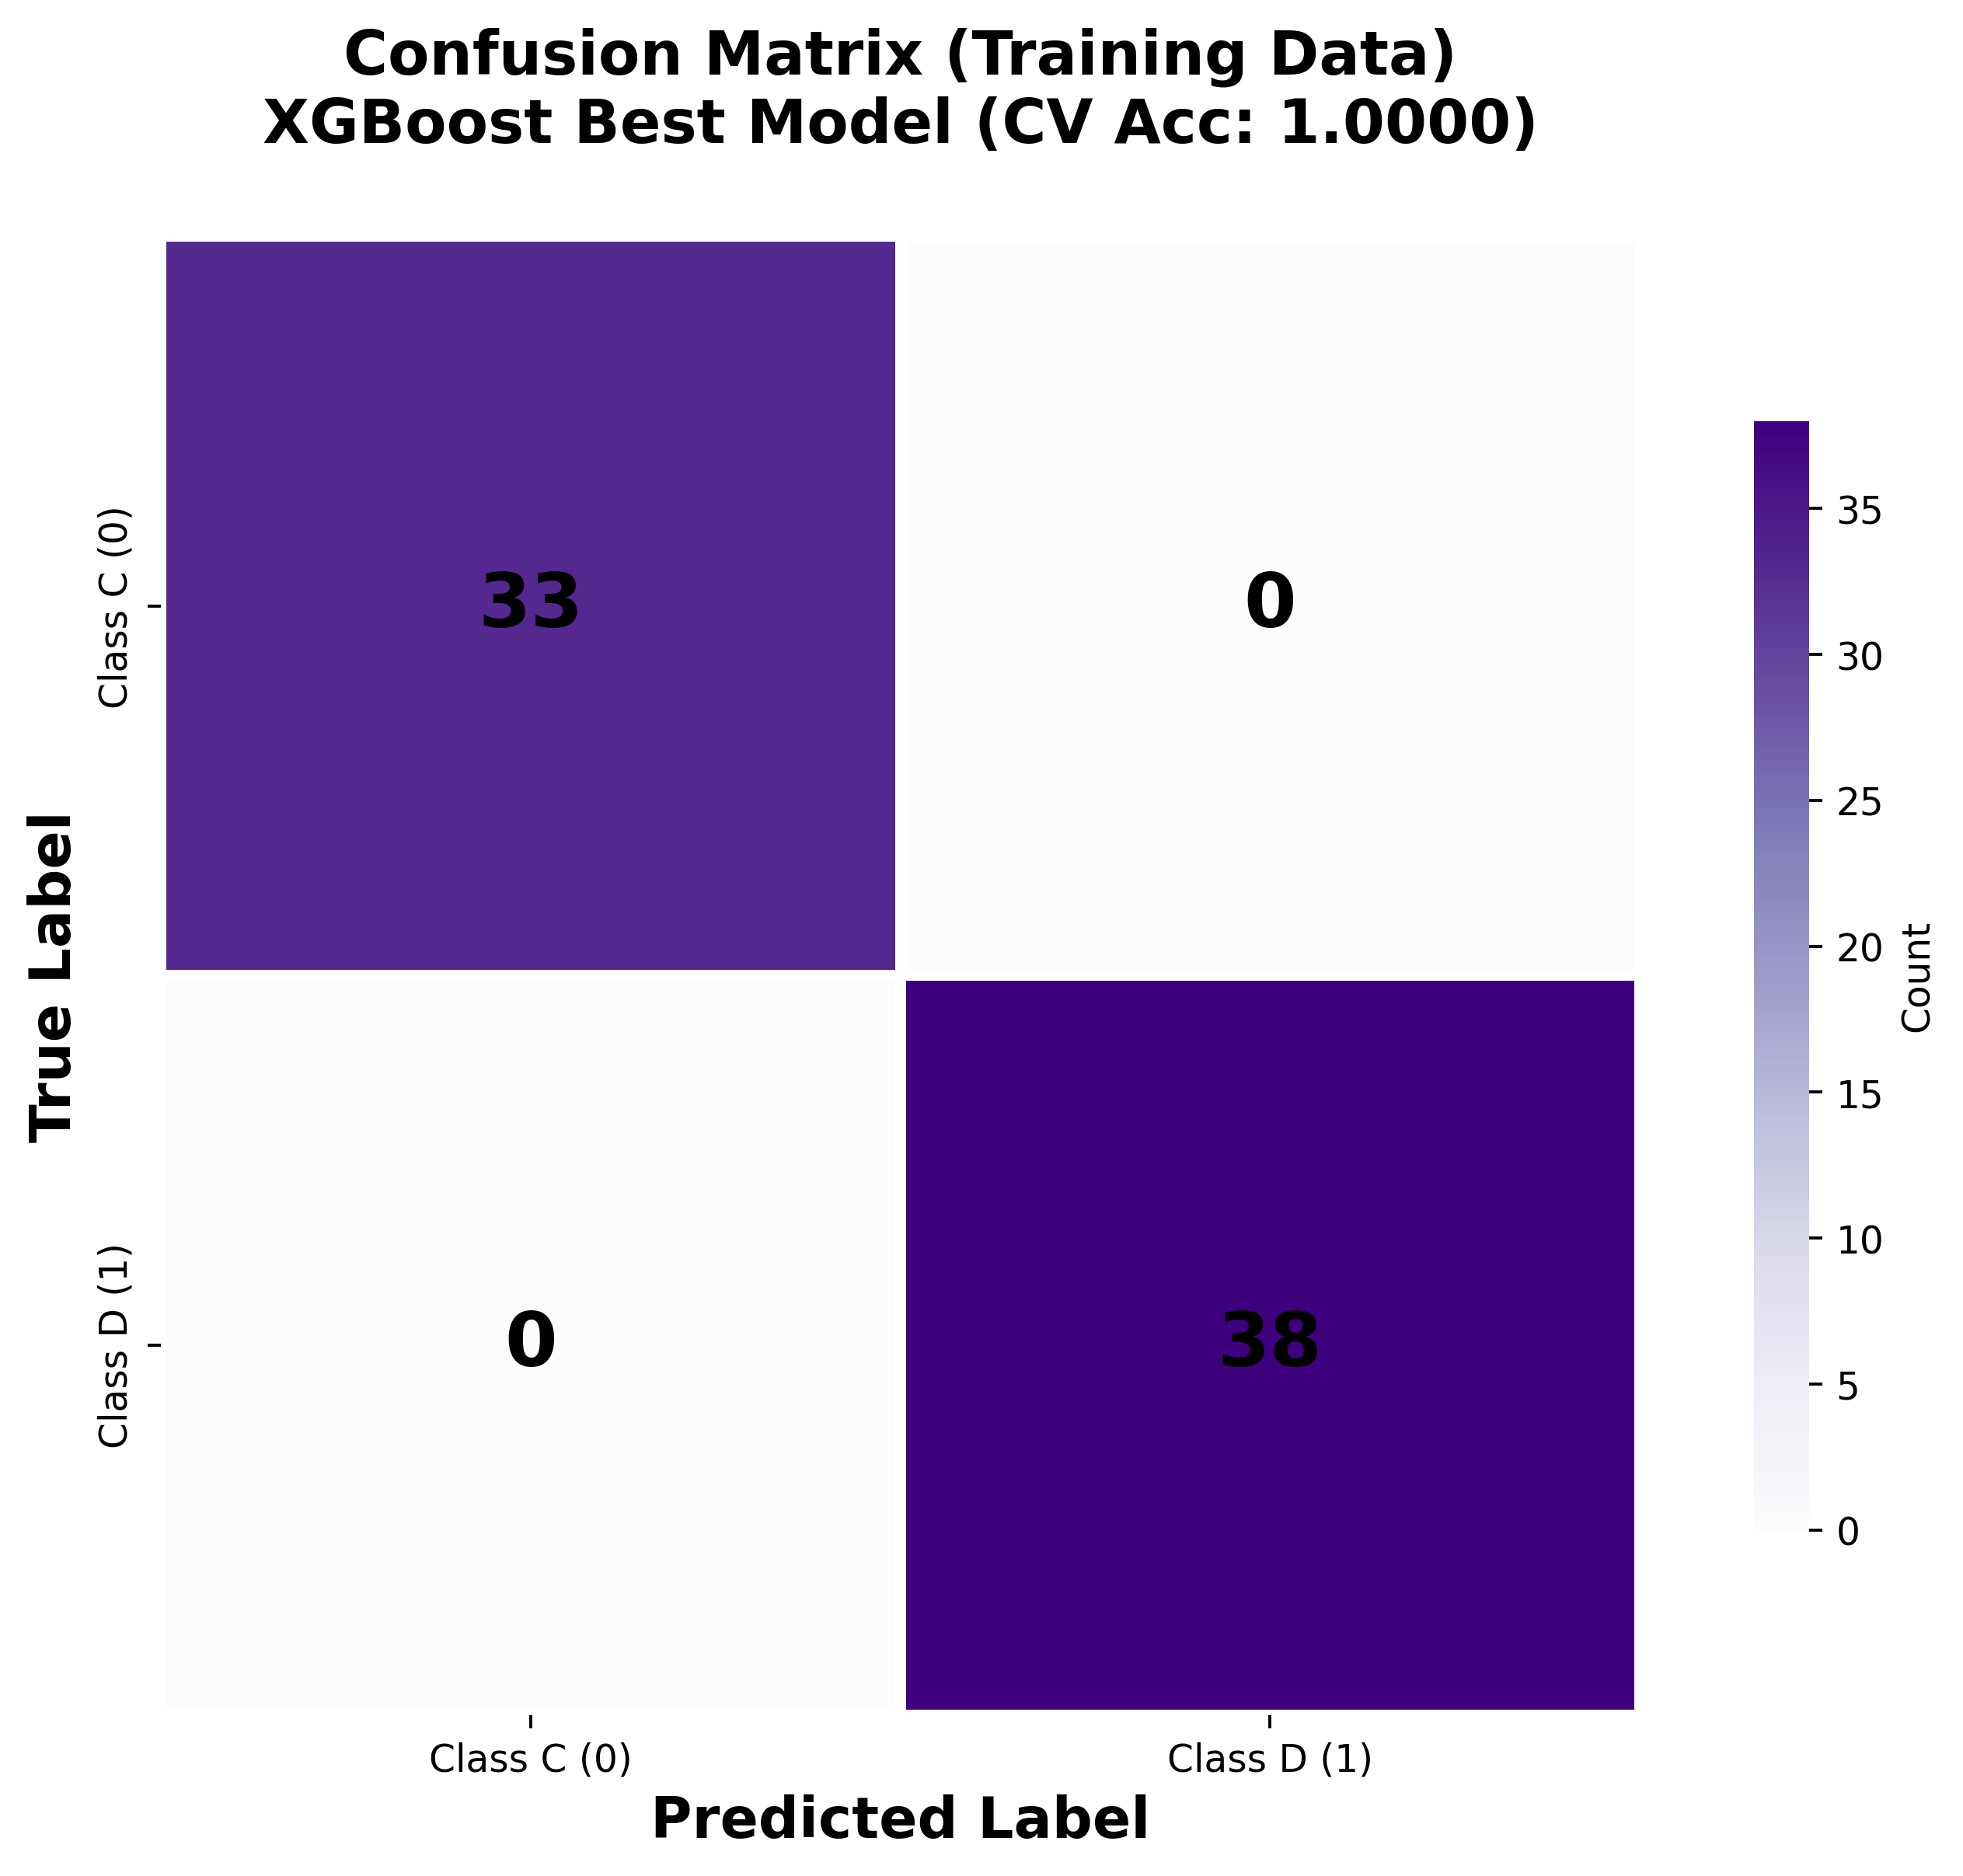

✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_20260529_160250.png'

FINAL MODEL PERFORMANCE ON TRAINING DATA
Best CV Accuracy : 1.0000
Training Accuracy: 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1-Score         : 1.0000
MCC              : 1.0000

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                33             0
True Class D                 0            38


In [ ]:



# ======================================================================
#  PINK CONFUSION MATRIX - BEST CV MODEL
# ======================================================================

y_pred = best_model.predict(X)
cm = confusion_matrix(y, y_pred)

plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nXGBoost Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.savefig(f'confusion_matrix_best_xgboost_{plot_timestamp}.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_{plot_timestamp}.png'")

# Metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE ON TRAINING DATA")
print("="*70)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\n" + "="*70)
print("CONFUSION MATRIX (Raw Counts)")
print("="*70)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")


Saved best model as: svm_linear_0.0001_model.pkl



Calculating SHAP values (this may take a moment)...


  0%|          | 0/71 [00:00<?, ?it/s]

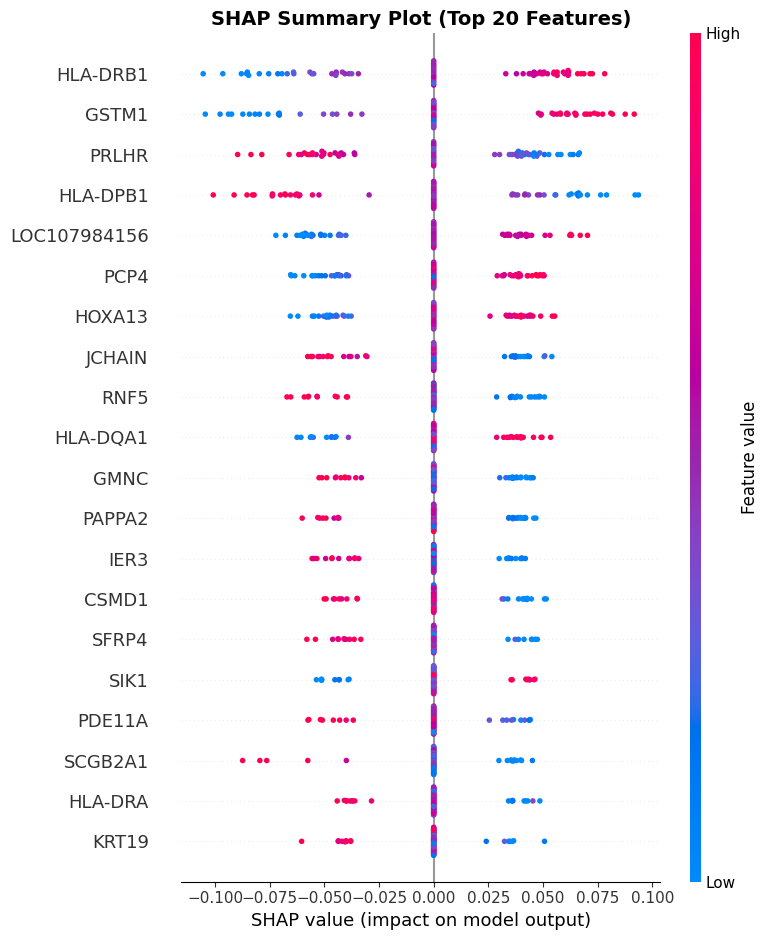

✅ SHAP importance saved as 'shap_importance.csv'

Top 10 SHAP Features:
     Feature  Mean_Abs_SHAP
    HLA-DRB1       0.045570
       GSTM1       0.040384
       PRLHR       0.038461
    HLA-DPB1       0.037407
LOC107984156       0.031445
        PCP4       0.028412
      HOXA13       0.025644
      JCHAIN       0.019471
        RNF5       0.017404
    HLA-DQA1       0.016868


In [ ]:

import shap
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SHAP ANALYSIS FOR SVM
# ============================================================

print("\nCalculating SHAP values (this may take a moment)...")

# Convert dataframe to numpy
X_array = X.values

# Small background sample for faster computation
background = shap.sample(X_array, 100, random_state=42)

# Feature names
feature_names = list(X.columns)

# For binary classification
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values[:, :, 1]


# ============================================================
# KERNEL EXPLAINER
# ============================================================

explainer = shap.KernelExplainer(
    best_model.predict_proba,
    background
)

# Compute SHAP values
shap_values = explainer.shap_values(X_array)

# --- 9a. SHAP Summary Plot (Beeswarm) ---
plt.figure()


shap.summary_plot(
    shap_vals,
    features=X_array,
    feature_names=feature_names,
    max_display=20,
    plot_type="dot",
    show=False
)

plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()


















# --- 9d. SHAP Feature Importance CSV ---

mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(shap_vals).mean(axis=0)
}).sort_values(
    'Mean_Abs_SHAP',
    ascending=False
).reset_index(drop=True)

mean_shap_df.to_csv(
    f'shap_importance.csv',
    index=False
)

print(f"✅ SHAP importance saved as 'shap_importance.csv'")

print("\nTop 10 SHAP Features:")

print(mean_shap_df.head(10).to_string(index=False))

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [3]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [4]:
data = merged.T

In [6]:


# Labels from row index
y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.values.astype(int)

# Feature matrix
data = data.reset_index(drop=True)
data.columns = data.iloc[0]
data = data.drop(data.index[0]).apply(pd.to_numeric)
X = data
y_val = y
X_val = X

import pickle
import joblib
model = joblib.load('/content/svm_linear_best_model.pkl')

# Open the file in read-binary mode



AttributeError: Can only use .str accessor with string values!

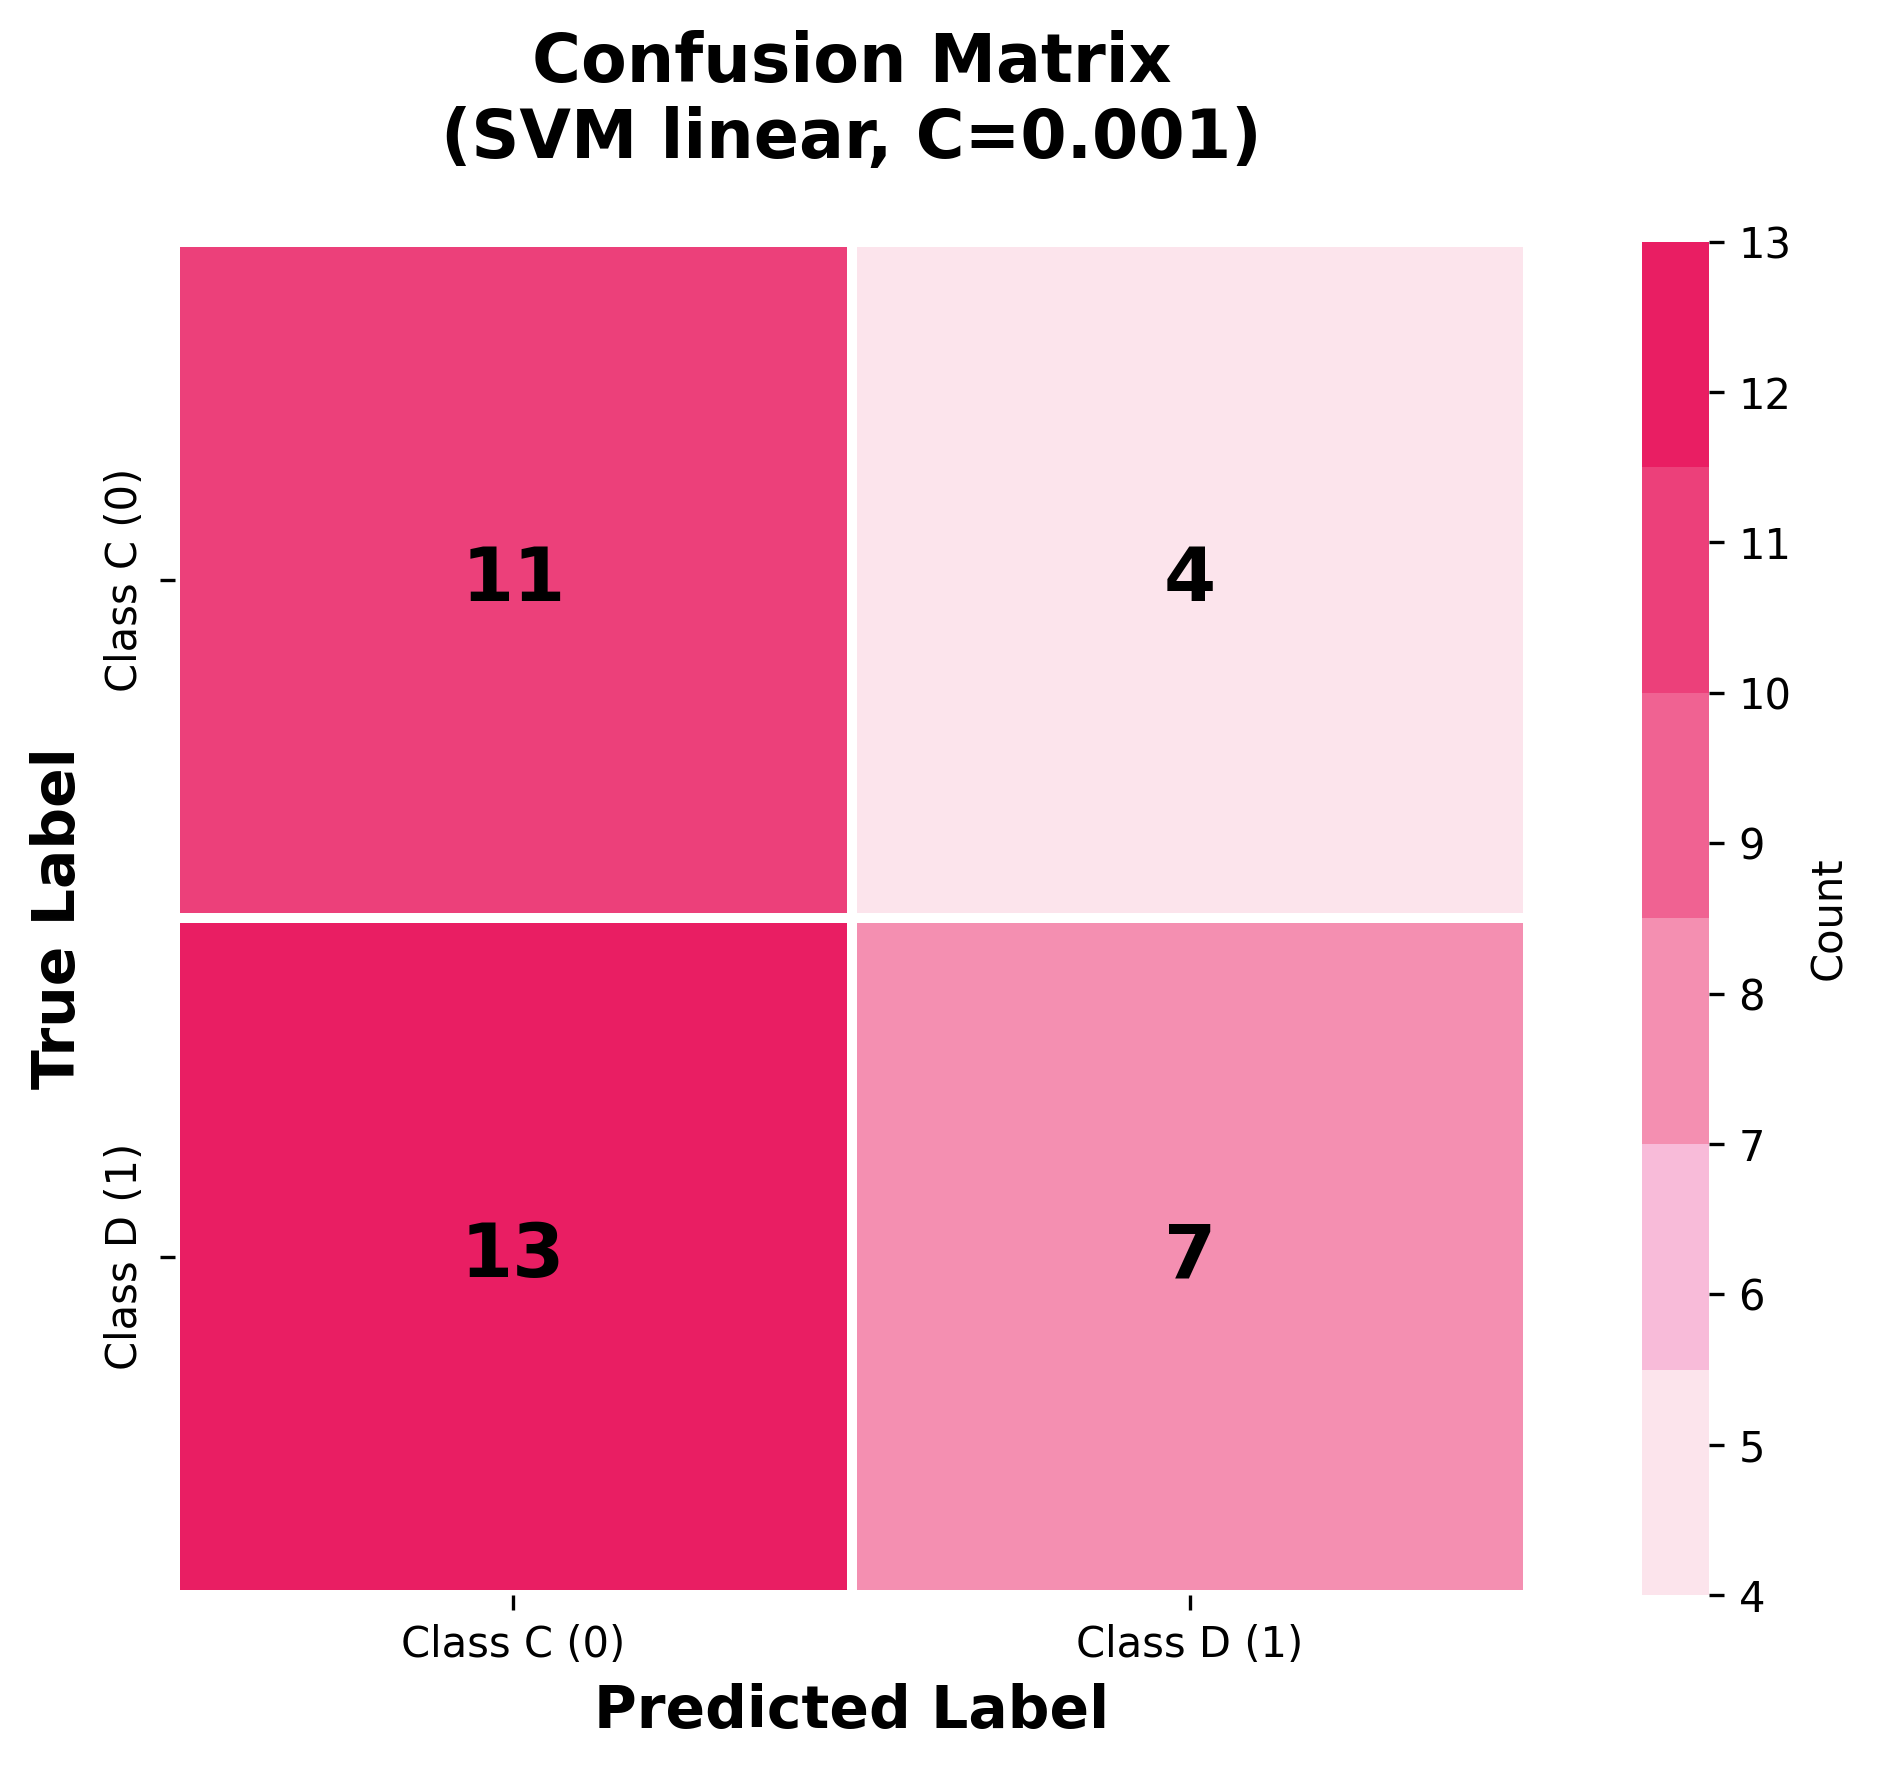


Saved as: confusion_matrix_pink.png

MODEL PERFORMANCE METRICS
Accuracy:  0.5143
Precision: 0.6364
Recall:    0.3500
F1-Score:  0.4516
MCC:       0.0888

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                11             4
True Class D                13             7


In [7]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

# ============================================================
# LOAD BEST MODEL
# ============================================================
with open("/content/drive/MyDrive/SVM_LINEAR/10_2/svm_linear_best_model.pkl", "rb") as f:
    best_model = pickle.load(f)

# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = best_model.predict(X)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y, y_pred)

# ============================================================
# PLOT ONE PINK CONFUSION MATRIX (BOXES ARE PINK)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pleasing pink colormap for the BOXES
pink_cmap = sns.color_palette(['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63'], as_cmap=True)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,       # PINK boxes
    cbar=True,           # Keep colorbar
    cbar_kws={'label': 'Count'},  # Colorbar label
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix\n(SVM linear, C={best_model.get_params()["C"]})',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('confusion_matrix_pink.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nSaved as: confusion_matrix_pink.png")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [8]:

import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime



# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.5143
ROC-AUC              : 0.5417
AUCPRC               : 0.5942
Avg Precision        : 0.5942
F1 Score             : 0.4516
F1 Macro             : 0.5079
F1 Weighted          : 0.4998
Precision            : 0.6364
Recall               : 0.3500
MCC                  : 0.0888

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.4583    0.7333    0.5641        15
           1     0.6364    0.3500    0.4516        20

    accuracy                         0.5143        35
   macro avg     0.5473    0.5417    0.5079        35
weighted avg     0.5601    0.5143    0.4998        35


✅ Metrics saved as 'validation_metrics_20260624_0558.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


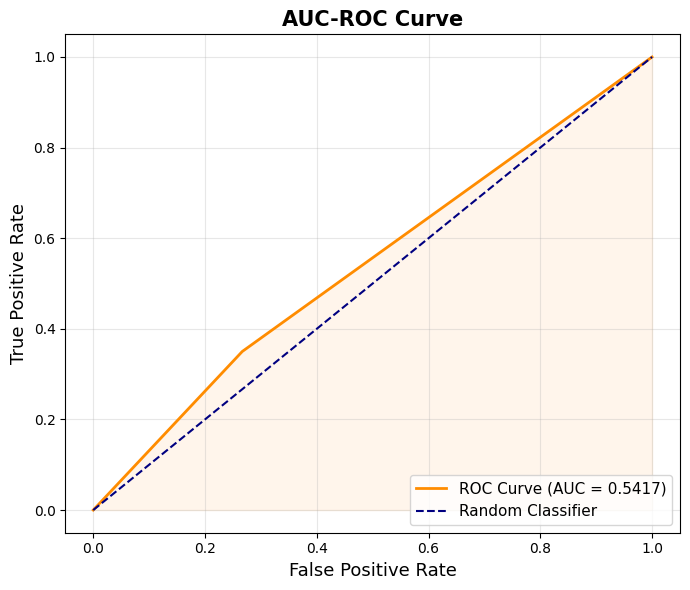

✅ AUC-ROC curve saved as 'aucroc_curve.png'


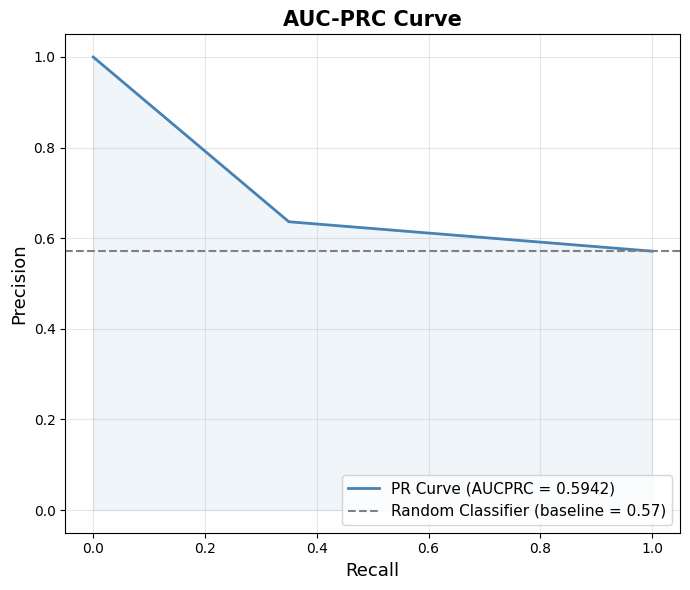

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [15]:
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")

